# Tutorials_ST_HE

In [1]:
import scanpy as sc
import torch
import os
import pandas as pd
import sys

In [2]:
import matplotlib.pyplot as plt

import community as louvain
import AgaeSMO as AgaeSMO_v1

AgaeSMO_v1.fix_seed(2022)

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [4]:
os.environ['R_HOME'] = '/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/R' 


data of demo deposited in https://drive.google.com/drive/folders/1eK5zSKmSV2eaQ9jhIEcKPXwuiWaGfldH?usp=sharing

In [5]:
adata_omics1 = sc.read_visium(path='data/orchid/Slide_1',
                              count_file="filtered_feature_bc_matrix.h5",
                              source_image_path="spatial")
adata_omics1.var_names_make_unique()

In [6]:
adata_omics1.var["mt"] = adata_omics1.var_names.str.startswith("MT-")
adata_omics1.var["ercc"] = adata_omics1.var_names.str.startswith("ERCC-")
sc.pp.calculate_qc_metrics(adata_omics1, qc_vars=["mt","ercc"], inplace=True)
sc.pp.filter_genes(adata_omics1, min_cells=3)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)


/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


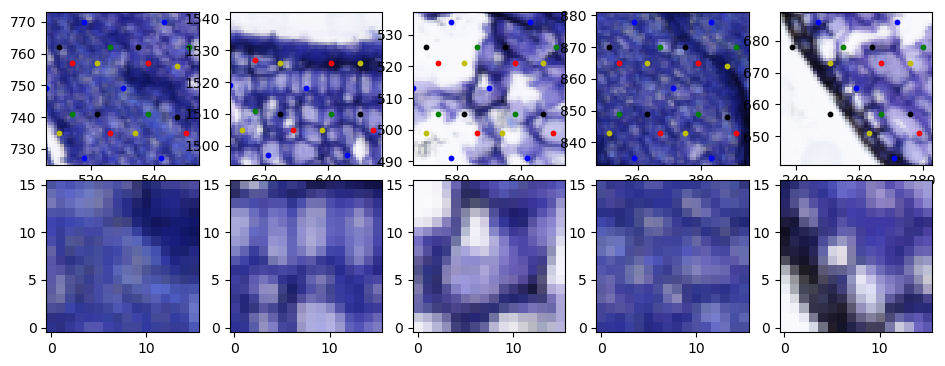

In [7]:

adata=adata_omics1.copy()
his_key=list(adata.uns["spatial"].keys())[0]
#int spot xy in his
adata.obsm["spatial_px"]=adata.obsm["spatial"]*adata.uns["spatial"][his_key]["scalefactors"]["tissue_hires_scalef"]
adata.obsm["spatial_px"]=adata.obsm["spatial_px"].astype(int)
# plot_spot_his(adata.uns["spatial"][his_key]["images"]["hires"],adata.obsm["spatial_px"])
#calculate box xy
r=8
adata=AgaeSMO_v1.calculate_box(adata,adata.obsm["spatial_px"],r)
adata.obsm['patch']=AgaeSMO_v1.his_path(adata,adata.uns["spatial"][his_key]["images"]["hires"])
adata.obsm["patch_flattern"]=adata.obsm["patch"].reshape(adata.obsm["patch"].shape[0],-1)
AgaeSMO_v1.check_patch_his(adata,his_key,r,save_path=None)
#counstruct his adata
adata_omics2=sc.AnnData(adata.obsm["patch_flattern"], dtype="float64")
adata_omics2.obs=adata.obs.copy()
adata_omics2.obsm=adata.obsm.copy()
adata_omics2.obsm['feat'] = AgaeSMO_v1.pca(adata_omics2, n_comps=50)
adata_omics2.obsm['tensor']=adata_omics2.X


In [8]:

adata_omics1.obsm['feat'] = AgaeSMO_v1.pca(adata_omics1[:, adata_omics1.var['highly_variable']], n_comps=50)
adata_omics1.obsm['tensor']=adata_omics1[:, adata_omics1.var['highly_variable']].X.toarray()

------Calculating spatial graph...
The graph contains 13592 edges, 2379 cells.
5.7133 neighbors per cell on average.
------Calculating spatial graph...


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


The graph contains 13592 edges, 2379 cells.
5.7133 neighbors per cell on average.


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


torch.Size([2379, 3000]) torch.Size([2379, 768])


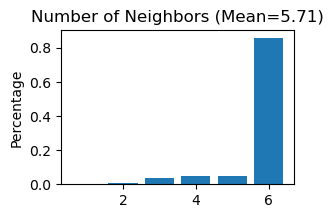

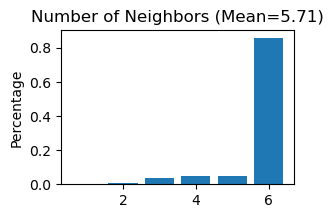

In [9]:

data = AgaeSMO_v1.construct_neighbor_graph(adata_omics1, adata_omics2,6,6,k=1)
# In[20]:


model = AgaeSMO_v1.Train_AgaeSMO(data, 
                             device=device,
                             learning_rate=0.001,
                             weight_decay=0,
                             epochs=1000,
                             loss_weight=[1,1,1,1],
                             loss_fun="sce")

In [10]:
output = model.train()

dim_input1 3000 dim_input2 768 
 dim_output1 30 dim_output2 30


  0%|          | 0/1000 [00:00<?, ?it/s]/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/layer.py:250: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(self.vu) + 1e-6)


epoch:0 2.231630802154541
epoch:10 0.8900532722473145
epoch:20 0.6542530059814453
epoch:30 0.5672029852867126
epoch:40 0.5292019248008728
epoch:50 0.5034826397895813
epoch:60 0.48116204142570496


  7%|▋         | 70/1000 [00:00<00:01, 481.31it/s]

epoch:70 0.4674921929836273
epoch:80 0.4541186988353729
epoch:90 0.4475562572479248
epoch:100 0.43704646825790405
epoch:110 0.4305034875869751


...

epoch:980 0.5262701511383057


 99%|█████████▉| 994/1000 [00:55<00:00, 16.69it/s]

epoch:990 0.5300549864768982


100%|██████████| 1000/1000 [00:55<00:00, 17.94it/s]


Model training finished!



In [11]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['AgaeSMO'] = output['AgaeSMO'].copy()
adata.obsm['alpha'] = output['alpha']

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


[<Axes: title={'center': 'AgaeSMO'}, xlabel='spatial1', ylabel='spatial2'>]

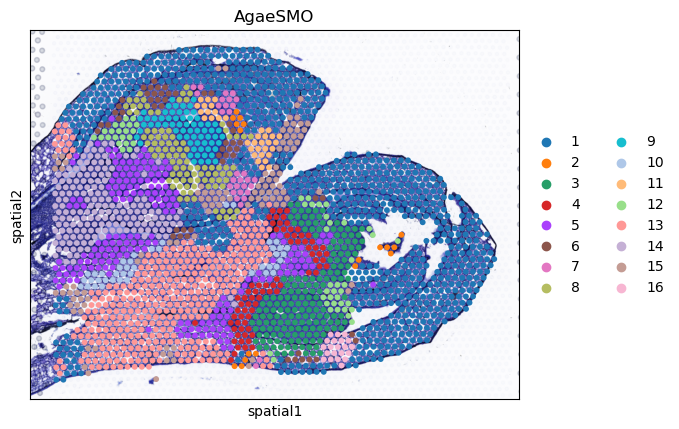

In [12]:

n_cluster=16
tool = 'mclust' # mclust, leiden, and louvain  
AgaeSMO_v1.clustering(adata,refine_=True, key='AgaeSMO', add_key='AgaeSMO', n_clusters=n_cluster, method="mclust", use_pca=True)# visualization

annotation=pd.read_csv("/public/home/off_liukunpeng/project/7_public_data/Data/osfstorage-archive/slide1_annotation.csv")
adata.obs["GrounTruth"]=list(annotation["annotation"])
indexs=AgaeSMO_v1.supervise_index(adata,"AgaeSMO",'GrounTruth')
ARI=indexs["ARI"]

fig, ax = plt.subplots()
sc.pl.spatial(adata, basis='spatial', color='AgaeSMO',ax=ax ,title='AgaeSMO', s=10, show=False)


